In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
car_df = pd.read_csv("CAR DETAILS FROM CAR DEKHO.csv")
car_df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [3]:
print("Shape:", car_df.shape)
print("\nMissing values:\n", car_df.isnull().sum())
print("\nDuplicate rows:", car_df.duplicated().sum())
print("\nData types:\n", car_df.dtypes)

Shape: (4340, 8)

Missing values:
 name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Duplicate rows: 763

Data types:
 name               str
year             int64
selling_price    int64
km_driven        int64
fuel               str
seller_type        str
transmission       str
owner              str
dtype: object


In [4]:
plt.style.use('seaborn-v0_8-darkgrid')
car_palette = ['#6C3483', '#E67E22', '#1F618D', '#17A589', '#C0392B']
sns.set_palette(car_palette)

In [5]:
rows_before = car_df.shape[0]
car_df = car_df.drop_duplicates().reset_index(drop=True)
rows_after = car_df.shape[0]

print("Rows before:", rows_before)
print("Rows after removing duplicates:", rows_after)
print("Duplicates removed:", rows_before - rows_after)

Rows before: 4340
Rows after removing duplicates: 3577
Duplicates removed: 763


**Cleaning note:** 763 duplicate listings were removed so the same car isn't counted twice during training.

In [6]:
from datetime import datetime

# Clean stray spaces in the text columns so categories stay consistent
for col in ['fuel', 'seller_type', 'transmission', 'owner']:
    car_df[col] = car_df[col].str.strip()

# Feature 1: car age (more useful to a model than the raw year)
current_year = datetime.now().year
car_df['car_age'] = current_year - car_df['year']

# Feature 2: brand = first word of the car name
car_df['brand'] = car_df['name'].str.split().str[0]
car_df['brand'] = car_df['brand'].replace({'Land': 'Land Rover', 'OpelCorsa': 'Opel'})

print(car_df['fuel'].value_counts())
car_df[['name', 'brand', 'year', 'car_age']].head()

fuel
Diesel      1800
Petrol      1717
CNG           37
LPG           22
Electric       1
Name: count, dtype: int64


,name,brand,year,car_age
0,Maruti 800 AC,Maruti,2007,19
1,Maruti Wagon R LXI Minor,Maruti,2007,19
2,Hyundai Verna 1.6 SX,Hyundai,2012,14
3,Datsun RediGO T Option,Datsun,2017,9
4,Honda Amaze VX i-DTEC,Honda,2014,12


**Feature engineering:** Created `car_age` from the manufacture year and extracted `brand` from the car name.

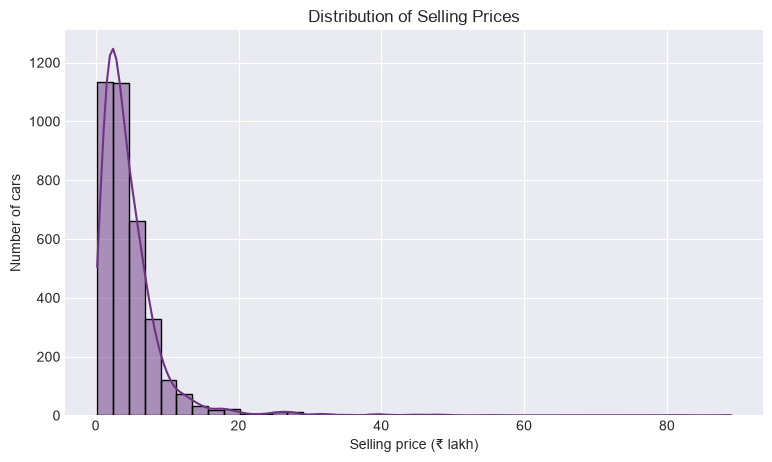

In [7]:
car_df['price_lakh'] = car_df['selling_price'] / 100000

plt.figure(figsize=(9, 5))
sns.histplot(car_df['price_lakh'], bins=40, kde=True, color='#6C3483')
plt.xlabel("Selling price (₹ lakh)")
plt.ylabel("Number of cars")
plt.title("Distribution of Selling Prices")
plt.show()

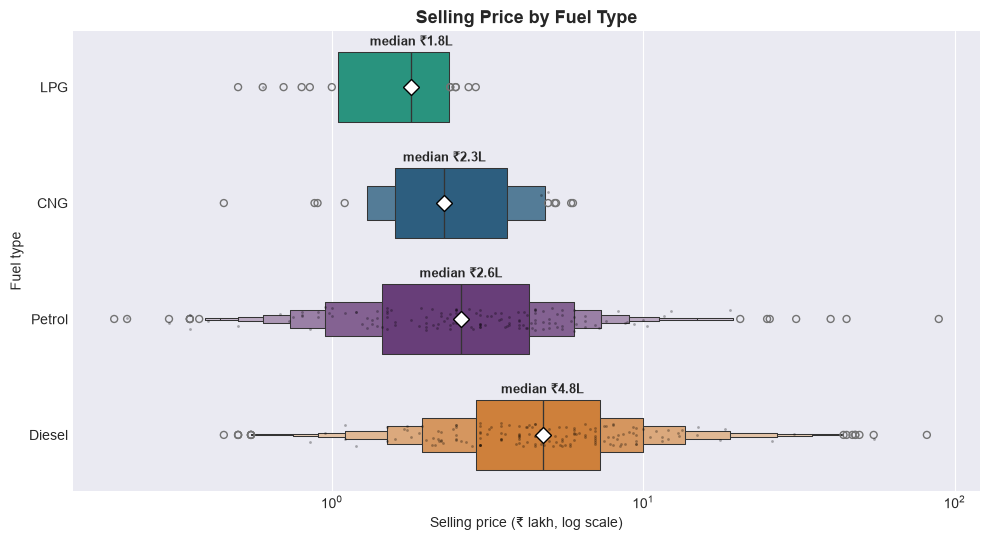

In [11]:
plot_df = car_df[car_df['fuel'] != 'Electric']   # only 1 electric car, too few to plot
order = plot_df.groupby('fuel')['price_lakh'].median().sort_values().index

fig, ax = plt.subplots(figsize=(10, 5.5))

sns.boxenplot(data=plot_df, x='price_lakh', y='fuel', order=order, hue='fuel',
              palette=car_palette[:4], legend=False, log_scale=True, width=0.6, ax=ax)

sns.stripplot(data=plot_df.sample(300, random_state=7), x='price_lakh', y='fuel',
              order=order, color='black', size=2, alpha=0.3, ax=ax)

for i, fuel in enumerate(order):
    med = plot_df.loc[plot_df['fuel'] == fuel, 'price_lakh'].median()
    ax.plot(med, i, marker='D', color='white', markeredgecolor='black', markersize=8, zorder=5)
    ax.annotate(f'median ₹{med:.1f}L', (med, i), xytext=(0, 30),
                textcoords='offset points', ha='center', fontsize=9,
                fontweight='bold', zorder=6)

ax.set_xlabel("Selling price (₹ lakh, log scale)")
ax.set_ylabel("Fuel type")
ax.set_title("Selling Price by Fuel Type", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

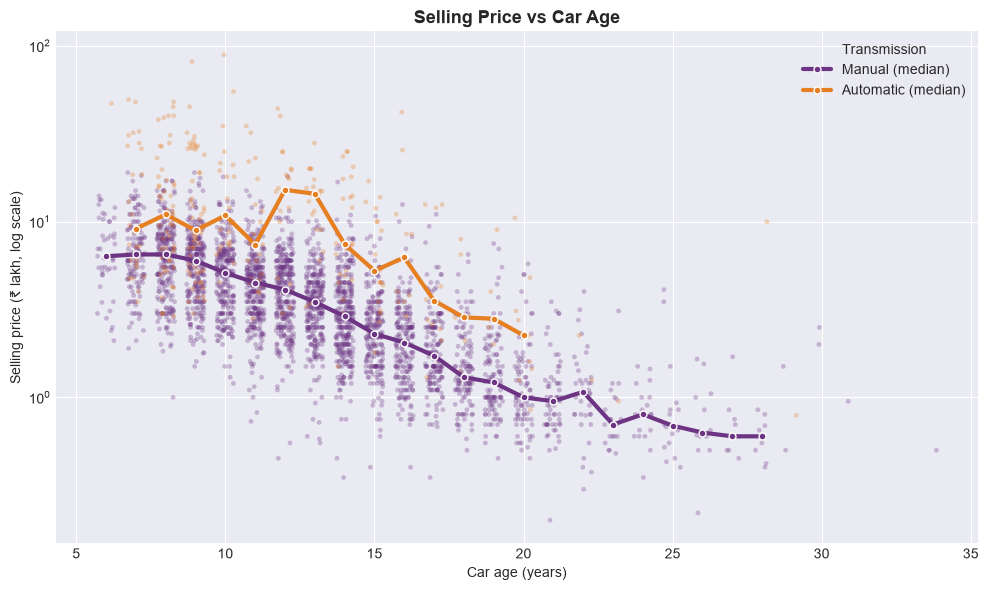

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
rng = np.random.default_rng(7)
shades = {'Manual': '#6C3483', 'Automatic': '#E67E22'}

for trans, col in shades.items():
    sub = car_df[car_df['transmission'] == trans]

    # small random shift so dots don't stack in straight columns
    jitter = rng.uniform(-0.3, 0.3, len(sub))
    ax.scatter(sub['car_age'] + jitter, sub['price_lakh'],
               s=12, alpha=0.30, color=col, edgecolors='none')

    # median price at each age (only ages with at least 5 cars)
    grp = sub.groupby('car_age')['price_lakh'].agg(['median', 'count'])
    grp = grp[grp['count'] >= 5]
    ax.plot(grp.index, grp['median'], color=col, lw=3, marker='o',
            markersize=5, markeredgecolor='white', label=f'{trans} (median)')

ax.set_yscale('log')
ax.set_xlabel("Car age (years)")
ax.set_ylabel("Selling price (₹ lakh, log scale)")
ax.set_title("Selling Price vs Car Age", fontsize=13, fontweight='bold')
ax.legend(title='Transmission', loc='upper right')
plt.tight_layout()
plt.show()

**Observation:** Car prices fall steadily as cars get older. Automatic cars sell for more than manual cars of the same age.|

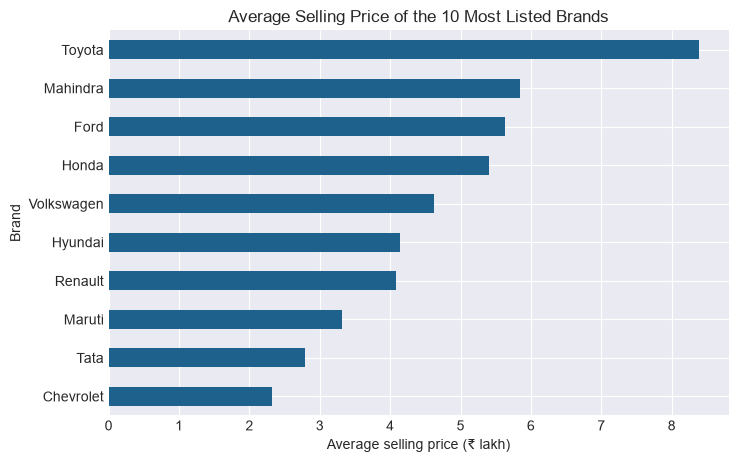

In [14]:
top_brands = car_df['brand'].value_counts().head(10).index
brand_avg = (car_df[car_df['brand'].isin(top_brands)]
             .groupby('brand')['price_lakh'].mean().sort_values())

plt.figure(figsize=(8, 5))
brand_avg.plot(kind='barh', color='#1F618D')
plt.xlabel("Average selling price (₹ lakh)")
plt.ylabel("Brand")
plt.title("Average Selling Price of the 10 Most Listed Brands")
plt.show()

In [15]:
feature_cols = ['car_age', 'km_driven', 'fuel', 'seller_type', 'transmission', 'owner', 'brand']

model_df = pd.get_dummies(car_df[feature_cols], drop_first=True, dtype=int)
target = car_df['price_lakh']

print("Feature table shape:", model_df.shape)
model_df.head()

Feature table shape: (3577, 41)


,car_age,km_driven,fuel_Diesel,fuel_Electric,fuel_LPG,fuel_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_Manual,owner_Fourth & Above Owner,...,brand_Mercedes-Benz,brand_Mitsubishi,brand_Nissan,brand_Opel,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,19,70000,0,0,0,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
1,19,50000,0,0,0,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,14,100000,1,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,9,46000,0,0,0,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,12,141000,1,0,0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


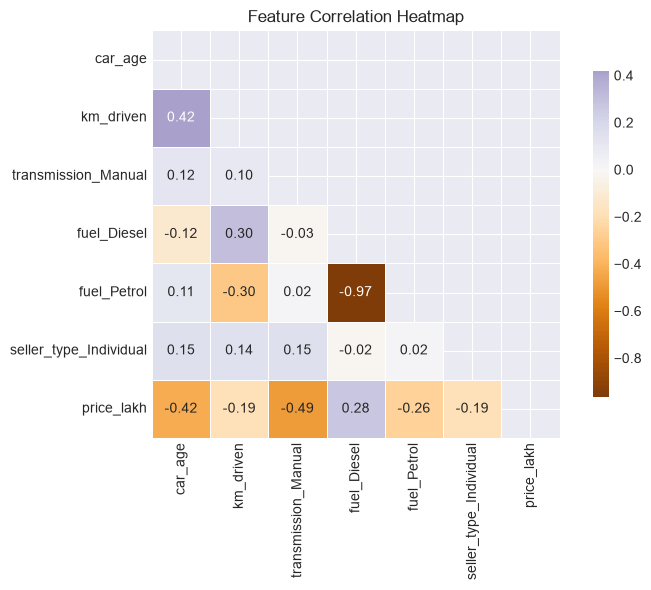

In [16]:
corr_cols = ['car_age', 'km_driven', 'transmission_Manual', 'fuel_Diesel',
             'fuel_Petrol', 'seller_type_Individual']

corr_df = model_df[corr_cols].copy()
corr_df['price_lakh'] = target
corr = corr_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))   # hide the repeated upper half

plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='PuOr', center=0,
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

**Observation:** Transmission type and car age have the strongest relationship with price. Manual cars and older cars sell for less, while diesel cars sell for more.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    model_df, target, test_size=0.2, random_state=21
)

print("Training cars:", X_train.shape[0])
print("Testing cars:", X_test.shape[0])

Training cars: 2861
Testing cars: 716


In [18]:
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)
pred_lin = lin_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=200, random_state=21, n_jobs=-1)
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

print("Both models trained successfully")

Both models trained successfully


In [19]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE (₹ lakh)': [mean_absolute_error(y_test, pred_lin),
                     mean_absolute_error(y_test, pred_rf)],
    'RMSE (₹ lakh)': [mean_squared_error(y_test, pred_lin) ** 0.5,
                      mean_squared_error(y_test, pred_rf) ** 0.5],
    'R² Score': [r2_score(y_test, pred_lin),
                 r2_score(y_test, pred_rf)]
}).round(3)

results

,Model,MAE (₹ lakh),RMSE (₹ lakh),R² Score
0,Linear Regression,1.747,3.915,0.576
1,Random Forest,1.578,4.004,0.557


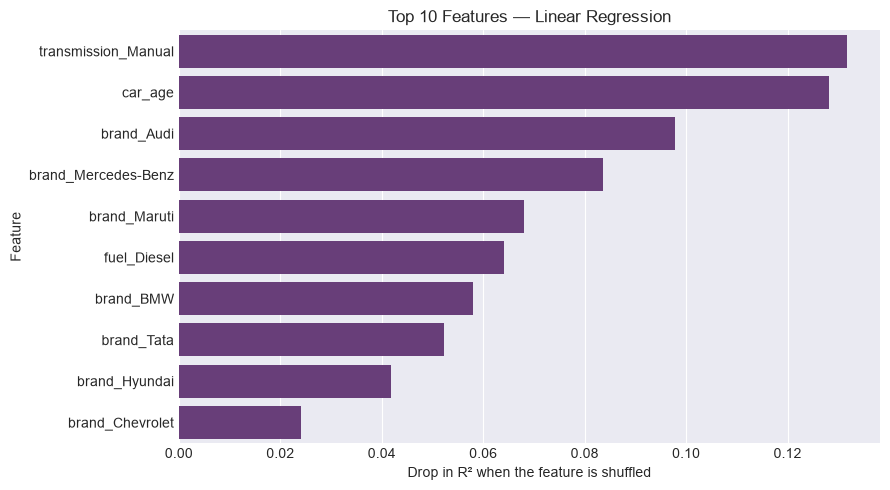

,Feature,Importance
8,transmission_Manual,0.132
0,car_age,0.128
13,brand_Audi,0.098
31,brand_Mercedes-Benz,0.084
30,brand_Maruti,0.068
2,fuel_Diesel,0.064
14,brand_BMW,0.058
37,brand_Tata,0.052
22,brand_Hyundai,0.042
15,brand_Chevrolet,0.024


In [20]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(lin_model, X_test, y_test,
                              n_repeats=10, random_state=21, scoring='r2')

imp_df = (pd.DataFrame({'Feature': model_df.columns,
                        'Importance': perm.importances_mean})
          .sort_values('Importance', ascending=False).head(10))

plt.figure(figsize=(9, 5))
sns.barplot(data=imp_df, x='Importance', y='Feature', color='#6C3483')
plt.xlabel("Drop in R² when the feature is shuffled")
plt.title("Top 10 Features — Linear Regression")
plt.tight_layout()
plt.show()

imp_df.round(3)

## Conclusion

Two regression models were trained to predict used car selling prices (in ₹ lakh):

| Model | MAE | RMSE | R² Score |
|---|---|---|---|
| Linear Regression | 1.75 | 3.92 | 0.58 |
| Random Forest | 1.58 | 4.00 | 0.56 |

**Best model: Linear Regression.** It has the highest R² (0.58) and the lowest RMSE. Random Forest
has a slightly lower average error (MAE), so the two models are close.

### Key Findings
- **Transmission type and car age are the strongest factors** — manual cars and older cars
  sell for less.
- **Brand has a large effect** — luxury brands (Audi, Mercedes-Benz, BMW) raise the predicted
  price, while budget brands (Maruti, Tata, Hyundai, Chevrolet) lower it.
- **Fuel type matters** — diesel cars tend to sell for more than petrol cars.

### Limitations
- A small number of very expensive luxury cars (up to ₹89 lakh) are hard to predict and pull the
  error up, which is why R² is only moderate.
- The dataset has no engine size, power or condition information. Adding these features would
  likely improve the predictions.